# Mean Forecast + Safety Stock

This notebook shows a clear workflow for using the mean forecast with safety stock:
generate synthetic data, split into backtest/forecast periods, calibrate a safety-stock
factor against the backtest window, then simulate and plot the forecast period.

**Scope note (rewritten against the new strategy-composed API, Task 14):** janrth's
original notebook optimized 300 articles at once via
`optimize_service_level_factors`/`simulate_replenishment_for_articles`, and also swept
an aggregation window via `optimize_aggregation_and_service_level_factors`. Neither of
those batch/aggregation helpers was ported into this repo (see `io_.py`'s module
docstring) -- only a single-policy `simulate_replenishment` and a single-policy
`calibration.optimize` exist here. This notebook therefore demonstrates the same
calibrate-then-simulate workflow on one article, using `ReplenishmentPolicy`,
`calibration.optimize`, and `simulate_replenishment` directly.

## Setup

In [1]:
from dataclasses import replace
import random

from replenishment.io_ import (
    generate_standard_simulation_rows, standard_simulation_rows_to_dataframe,
    standard_simulation_rows_from_dataframe, split_standard_simulation_rows,
    build_policy_from_standard_rows, replenishment_decision_rows_to_dataframe,
    ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.safety_stock import SqrtHorizonSafetyStock
from replenishment.strategies.order_trigger import OrderUpToTrigger, ReorderPointTrigger
from replenishment.viz import plot_replenishment_decisions

### Policy cadence parameters (review cycle + forecast horizon)

Set the order cadence (**review_period**) and the coverage window (**forecast_horizon**,
excluding lead time). The policy uses a total horizon of **lead_time + forecast_horizon**.

In [2]:
review_period = 1
forecast_horizon = 1
lead_time = 3

## Generate Sample Data

In [3]:
history_mean = 18
history_std = 8
forecast_mean = 16
forecast_std = 2
replenishment_start_period = 90

rows = generate_standard_simulation_rows(
    n_unique_ids=1,
    periods=120,
    history_mean=history_mean,
    history_std=history_std,
    forecast_mean=forecast_mean,
    forecast_std=forecast_std,
    holding_cost_per_unit=1,
    stockout_cost_per_unit=5.0,
    order_cost_per_order=12.5,
    seed=7,
    lead_time=lead_time,
    forecast_start_period=replenishment_start_period,
)
df = standard_simulation_rows_to_dataframe(rows, library="pandas")

# Overwrite current stock to simulate a known starting inventory position.
df["current_stock"] = 25

# Drop is_forecast so the cutoff defines the backtest/evaluation split.
df = df.drop(columns=["is_forecast"])

cutoff_period = replenishment_start_period
cutoff = sorted(df["ds"].unique())[cutoff_period - 1]
rows = standard_simulation_rows_from_dataframe(df, cutoff=cutoff)

candidate_factors = [.1, .12, .14, .16, .18, .2, .22, .24, .26, .28, .3, .32, .34, .36, .38, .4, .42, .5,
                     .6, .62, .64, .66, .68, 0.7, .72, .74, .76,
                     .78, 0.8, .82, .84, .86, .88, .90, .92, .94, 1, 1.1, 1.2, 1.3, 1.5, 1.7, 1.9, 2,
                     2.2, 2.5]

## Split Backtest vs Forecast

In [4]:
backtest_rows, forecast_rows = split_standard_simulation_rows(rows)
backtest_rows = sorted(backtest_rows, key=lambda r: r.ds)
forecast_rows = sorted(forecast_rows, key=lambda r: r.ds)

# Add simulated actuals for the forecast/evaluation period.
rng = random.Random(7)
def _sample_int(mean: float, std: float) -> int:
    return max(0, int(round(rng.gauss(mean, std))))

forecast_rows = [
    replace(row, actuals=_sample_int(history_mean, history_std), demand=_sample_int(history_mean, history_std))
    for row in forecast_rows
]

backtest_actuals = [int(r.actuals) for r in backtest_rows]
print(f"backtest periods: {len(backtest_rows)}, forecast periods: {len(forecast_rows)}")

backtest periods: 90, forecast periods: 30


## Step 1: Optimize Safety Stock (order-up-to policy)

In [5]:
result = optimize(
    candidate_builder=lambda factor: build_policy_from_standard_rows(
        backtest_rows, safety_stock_builder=lambda: SqrtHorizonSafetyStock(factor=factor),
        trigger=OrderUpToTrigger(), lead_time=lead_time,
    ),
    candidate_values=candidate_factors,
    periods=len(backtest_rows), demand=[r.actuals for r in backtest_rows],
    initial_on_hand=25, lead_time=lead_time, holding_cost_per_unit=1, stockout_cost_per_unit=5.0,
)
best_factor = result.best_value
best_factor, result.best_validation_cost

(2.5, 743.0)

Simulate the forecast period with the calibrated factor. Since `forecast_rows` only has
`forecast` values (no actuals except what we simulated above for evaluation), we reuse the
backtest actuals series for the safety-stock error calculation (mirrors janrth's
`actuals_override=backtest_actuals` pattern) and evaluate against the freshly simulated
forecast-period actuals.

In [6]:
eval_policy = ReplenishmentPolicy.order_up_to(
    forecast=TimeSeries.from_values([r.forecast for r in forecast_rows]),
    actuals=TimeSeries.from_values(backtest_actuals),
    safety_stock=SqrtHorizonSafetyStock(factor=best_factor),
    lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
)
current_stock = forecast_rows[0].current_stock
simulation = simulate_replenishment(
    periods=len(forecast_rows), demand=[r.demand for r in forecast_rows], initial_on_hand=current_stock,
    lead_time=lead_time, policy=eval_policy,
    holding_cost_per_unit=forecast_rows[0].holding_cost_per_unit,
    stockout_cost_per_unit=forecast_rows[0].stockout_cost_per_unit,
    order_cost_per_order=forecast_rows[0].order_cost_per_order,
)

mean_decision_rows = [
    ReplenishmentDecisionRow(
        unique_id=row.unique_id, ds=row.ds, quantity=snapshot.order_placed,
        demand=snapshot.demand, incoming_stock=snapshot.received,
        starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
        on_order=snapshot.on_order, backorders=snapshot.backorders, sigma=best_factor,
    )
    for row, snapshot in zip(forecast_rows, simulation.snapshots)
]
mean_decision_df = replenishment_decision_rows_to_dataframe(mean_decision_rows, library="pandas")
mean_decision_df

,unique_id,ds,quantity,demand,forecast_quantity,forecast_quantity_lead_time,reorder_point,order_up_to,incoming_stock,starting_stock,...,current_stock,on_order,backorders,missed_sales,sigma,aggregation_window,review_period,forecast_horizon,rmse_window,percentile_target
0,A,2031-05-24,16,22,None,None,None,None,0,None,...,None,16,0,None,2.5,None,None,None,None,None
1,A,2031-06-23,22,15,None,None,None,None,0,None,...,None,38,12,None,2.5,None,None,None,None,None
2,A,2031-07-23,0,16,None,None,None,None,0,None,...,None,38,16,None,2.5,None,None,None,None,None
3,A,2031-08-22,11,21,None,None,None,None,16,None,...,None,33,5,None,2.5,None,None,None,None,None
4,A,2031-09-21,13,20,None,None,None,None,22,None,...,None,24,0,None,2.5,None,None,None,None,None
5,A,2031-10-21,6,19,None,None,None,None,0,None,...,None,30,17,None,2.5,None,None,None,None,None
6,A,2031-11-20,10,25,None,None,None,None,11,None,...,None,29,14,None,2.5,None,None,None,None,None
7,A,2031-12-20,15,22,None,None,None,None,13,None,...,None,31,9,None,2.5,None,None,None,None,None
8,A,2032-01-19,10,4,None,None,None,None,6,None,...,None,35,0,None,2.5,None,None,None,None,None
9,A,2032-02-18,21,14,None,None,None,None,10,None,...,None,46,2,None,2.5,None,None,None,None,None


### Plot

<Axes: title={'center': 'Replenishment for A'}, xlabel='Date', ylabel='Units'>

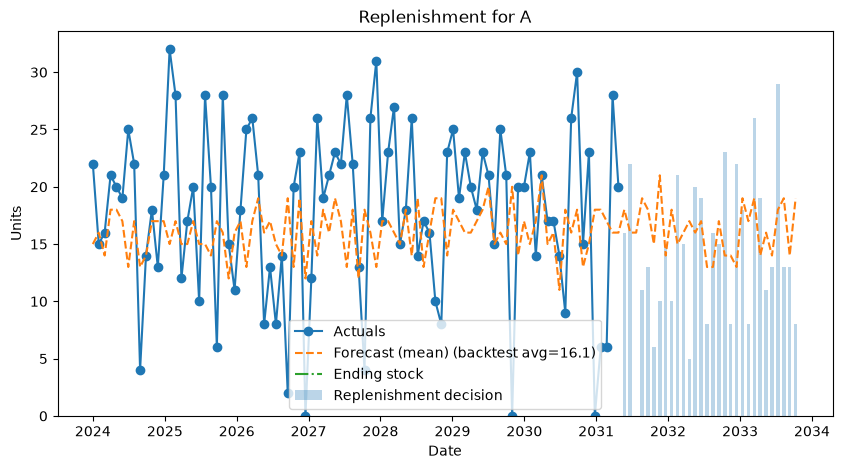

In [7]:
example_id = df["unique_id"].iloc[0]
plot_replenishment_decisions(df, mean_decision_df, unique_id=example_id)

## ROP policy (mean + safety stock)

This section uses a reorder-point trigger instead of ordering every period.

<Axes: title={'center': 'Replenishment for A'}, xlabel='Date', ylabel='Units'>

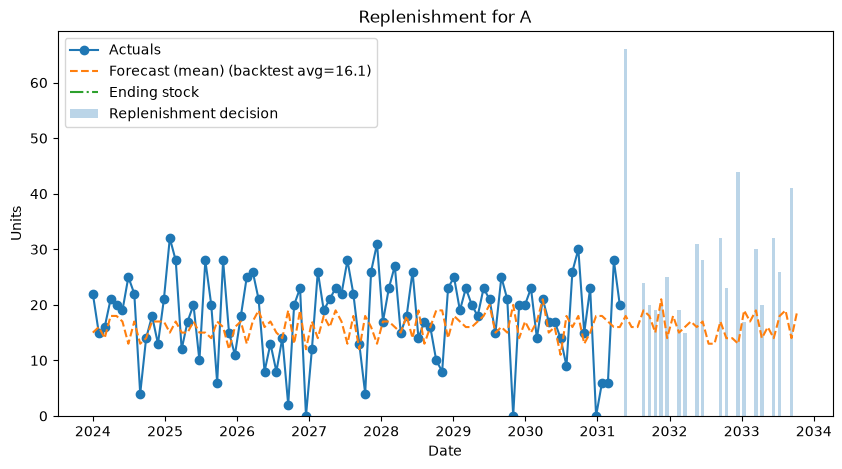

In [8]:
rop_result = optimize(
    candidate_builder=lambda factor: build_policy_from_standard_rows(
        backtest_rows, safety_stock_builder=lambda: SqrtHorizonSafetyStock(factor=factor),
        trigger=ReorderPointTrigger(), lead_time=lead_time,
    ),
    candidate_values=candidate_factors,
    periods=len(backtest_rows), demand=[r.actuals for r in backtest_rows],
    initial_on_hand=25, lead_time=lead_time, holding_cost_per_unit=1, stockout_cost_per_unit=5.0,
)
rop_best_factor = rop_result.best_value

rop_policy = ReplenishmentPolicy.reorder_point(
    forecast=TimeSeries.from_values([r.forecast for r in forecast_rows]),
    actuals=TimeSeries.from_values(backtest_actuals),
    safety_stock=SqrtHorizonSafetyStock(factor=rop_best_factor),
    lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
)
rop_simulation = simulate_replenishment(
    periods=len(forecast_rows), demand=[r.demand for r in forecast_rows], initial_on_hand=current_stock,
    lead_time=lead_time, policy=rop_policy,
    holding_cost_per_unit=forecast_rows[0].holding_cost_per_unit,
    stockout_cost_per_unit=forecast_rows[0].stockout_cost_per_unit,
    order_cost_per_order=forecast_rows[0].order_cost_per_order,
)
rop_decision_rows = [
    ReplenishmentDecisionRow(
        unique_id=row.unique_id, ds=row.ds, quantity=snapshot.order_placed,
        demand=snapshot.demand, incoming_stock=snapshot.received,
        starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
        on_order=snapshot.on_order, backorders=snapshot.backorders, sigma=rop_best_factor,
    )
    for row, snapshot in zip(forecast_rows, rop_simulation.snapshots)
]
rop_decision_df = replenishment_decision_rows_to_dataframe(rop_decision_rows, library="pandas")
plot_replenishment_decisions(df, rop_decision_df, unique_id=example_id)